# CONNECT TO running server as client

In [1]:
# server has to run first (buildandrun powershell)

In [2]:
# OLD CODE - keep in case
# this code lets you send messages to the server but can not receive from server to jupyter client 
  
# import socketio
# sio = socketio.Client()
# sio.disconnect()

# uid = 'jupyter-client'

# @sio.event(namespace='/main')
# def connect():
#     print("✅ Connected to /main")


# # Variables to store received data
# latest_data = None
# message_log = []

# # jupyter client listener for server events 
# @sio.on('ex', namespace='/main')
# def on_ex(data):
#     global latest_data, message_log
#     print(f"📩 Server returned on 'ex': {data}")
#     latest_data = data
#     message_log.append({'event': 'ex', 'data': data}

#     # Example: auto-react
#     if data.get('fn') == 'dropdown' and data.get('id') == 'projDD':
#         print("🧠 Project updated:", data.get('val'))
 
# # establish a connection to the server as another client 
# sio.connect('http://127.0.0.1:5000', namespaces=['/main'])
# sio.emit('join', {'usr': uid}, namespace='/main')
# sio.emit('init-project', namespace='/main')
# -----------------------------------------------------------------------------------------

import socketio
import time
import threading

# Setup Socket.IO client
sio = socketio.Client()
uid = 'jupyter-client'

latest_data = None
message_log = []

# 1️⃣ Define listeners BEFORE connect
@sio.on('ex', namespace='/main')
def on_ex(data):
    global latest_data, message_log
    print(f"📩 Server returned on 'ex': {data}")
    latest_data = data
    message_log.append({'event': 'ex', 'data': data})

@sio.event(namespace='/main')
def connect():
    print("✅ Connected to /main")
    sio.emit('join', {'usr': uid}, namespace='/main')

# 2️⃣ Connect
sio.connect('http://127.0.0.1:5000', namespaces=['/main'])

# 3️⃣ Start background thread AFTER connect
def wait_forever():
    while True:
        time.sleep(1)

thread = threading.Thread(target=wait_forever)
thread.daemon = True
thread.start()

print("📡 Listening for messages in the background...")


📡 Listening for messages in the background...
✅ Connected to /main


📩 Server returned on 'ex': {'usr': 'jupyter-client', 'val': {'name': 'imunet_250130-X1-inter', 'layouts': ['Inter-layers'], 'layoutsRGB': ['Inter-layers'], 'links': ['Inter-layers'], 'linksRGB': ['Inter-layers'], 'selections': [], 'scenes': ['Inter-layers'], 'info': 'No description specified.', 'linkcount': 5133, 'labelcount': 0, 'nodecount': 85107, 'labels': [85107, 0], 'annotationTypes': True}, 'fn': 'project'}
📩 Server returned on 'ex': {'usr': 'jupyter-client', 'fn': 'layout', 'id': 'layoutExists', 'val': False}
📩 Server returned on 'ex': {'usr': 'jupyter-client', 'id': 'projDD', 'fn': 'dropdown', 'parent': 'projDD', 'sel': 11, 'name': 'imunet_250130-X1-inter'}
📩 Server returned on 'ex': {'id': 'x', 'success': 'true', 'fn': 'projectLoaded', 'usr': 'sKxrS3Sb0x'}
📩 Server returned on 'ex': {'usr': 'sKxrS3Sb0x', 'id': 'module-project', 'fn': 'moduleState', 'val': True}
📩 Server returned on 'ex': {'usr': 'EJ7MEhDdPL', 'id': 'module-project', 'fn': 'moduleState', 'val': True}
📩 Server r

### sending from jupyter-client to others (e.g. webclient)

In [3]:
# basic example 
# sio.emit('ex', {
#     'usr': 'jupyter-client',
#     'msg': 'Node: 20', 'id': None, 'val': '20', 'fn': 'node'
# }, namespace='/main')


### change project 

In [4]:
# get all projects in backend 

import GlobalData as GD

# print as pretty table with index from  0 - x
allprojects = []
for i, proj in enumerate(GD.listProjects()):
    allprojects.append((i,proj))
allprojects

[(0, 'ATEST'),
 (1, 'ATEST-2'),
 (2, 'ATEST-3'),
 (3, 'ATEST-4'),
 (4, 'CDK5'),
 (5, 'CircLadderGraph-xsmall'),
 (6, 'diffusion'),
 (7, 'Exposurome'),
 (8, 'GenExpression_01'),
 (9, 'GenExpression_02'),
 (10, 'imunet_250130-X0-inter'),
 (11, 'imunet_250130-X1-inter'),
 (12, 'Interactive_Project_T01'),
 (13, 'JSON_autocore'),
 (14, 'JSON_barbellgraph'),
 (15, 'JSON_Zachary'),
 (16, 'Realtime-project'),
 (17, 'Sphere_Torus'),
 (18, 'Teapot'),
 (19, 'TheMandelbulb_edges')]

In [5]:
# choose a project id from list above to change project 
sel_index = 11

sel_id = allprojects[sel_index][0]
sel_name = allprojects[sel_index][1]

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': 'dropdown',
    'val': sel_id,
    'msg' : sel_name,
    'id': 'projDD',
}, namespace='/main')

### receive messages from server or web/VR client

In [6]:
# SEND DATA - select a node via jupyter client
sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': 'node',
    'val': '2534', #1398',
    'msg' : '', #'CDK5',
    'id': None,
}, namespace='/main')

In [7]:
# SELECT SOMETHING on Web/VR client and check if received here on jupyter client : 
print("📦 Latest data received:", latest_data)

📦 Latest data received: None


# next 

In [8]:
# workflow

# 1. create a project with jupyter client - only nx.Graph with nodes/edges - nothing else 
# 2. in VR - select the project (see random layout as default)
# 3. in jupyter client - make global layout
# 4. in VR client look at patterns - select a node
# 5. in jupyter client - get all neighbors of selected node - then relayout with subgraph in center and sphere around 
# 6. in VR client - see the new layout
# 7. 


In [9]:
# small network project 
import networkx as nx 

G = nx.circular_ladder_graph(20)
G.graph['projectname'] = 'Realtime-project'

print("number of G nodes = ", len(G.nodes))   
print("number of G edges = ", len(G.edges))


number of G nodes =  40
number of G edges =  60


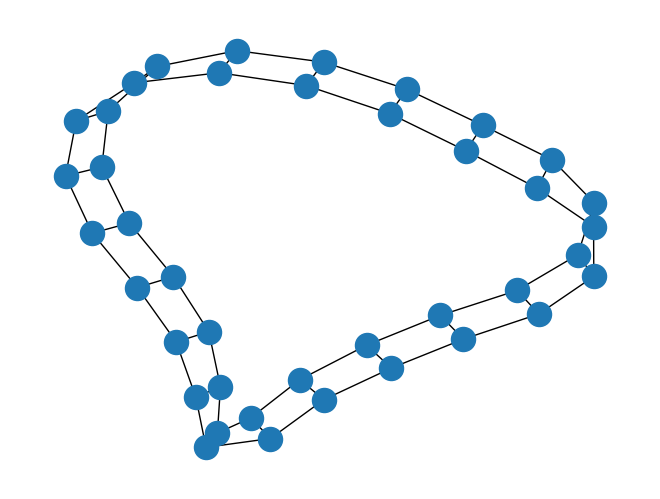

In [10]:
nx.draw(G)

In [11]:
# make project in backend

import nx2json as nx2j 

nx2j.create_project(G)

Merged JSON file saved as:  c:\Users\chris\Desktop\GIT\DataDiVR_WebApp\Realtime-project.json
Successfully created the directory static/projects/Realtime-project 
PROGRESS: loaded graph JSON...
PROGRESS: stored graph data...
PROGRESS: stored layouts...
PROGRESS: stored node info...
PROGRESS: made node position textures...
PROGRESS: made textures for node colors...
PROGRESS: made textures for links and stored all links in links.json ...
PROGRESS: made textures for link colors...
PROGRESS: writing json files for project and nodes...
Project created successfully.


In [14]:
# see if new project is in projectlist 

allprojects_updated = []
for i, proj in enumerate(GD.listProjects()):
    allprojects_updated.append((i,proj))
allprojects_updated

[(0, 'ATEST'),
 (1, 'ATEST-2'),
 (2, 'ATEST-3'),
 (3, 'ATEST-4'),
 (4, 'CDK5'),
 (5, 'CircLadderGraph-xsmall'),
 (6, 'diffusion'),
 (7, 'Exposurome'),
 (8, 'GenExpression_01'),
 (9, 'GenExpression_02'),
 (10, 'imunet_250130-X0-inter'),
 (11, 'imunet_250130-X1-inter'),
 (12, 'Interactive_Project_T01'),
 (13, 'JSON_autocore'),
 (14, 'JSON_barbellgraph'),
 (15, 'JSON_Zachary'),
 (16, 'Realtime-project'),
 (17, 'Sphere_Torus'),
 (18, 'Teapot'),
 (19, 'TEAPOTx'),
 (20, 'TEAPOTx-16384'),
 (21, 'TheMandelbulb_edges')]

In [16]:
# choose a project id from list above to change project 
sel_index = 20

sel_id = allprojects_updated[sel_index][0]
sel_name = allprojects_updated[sel_index][1]

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': 'dropdown',
    'val': sel_id,
    'msg' : sel_name,
    'id': 'projDD',
}, namespace='/main')

📩 Server returned on 'ex': {'usr': 'jupyter-client', 'val': {'name': 'TheMandelbulb_edges', 'layouts': ['pt_cloud0', 'pt_cloud2', 'pt_cloud3'], 'layoutsRGB': ['pt_cloud0', 'pt_cloud2', 'pt_cloud3'], 'links': ['pt_cloud0', 'pt_cloud2', 'pt_cloud3'], 'linksRGB': ['pt_cloud0', 'pt_cloud2', 'pt_cloud3'], 'selections': [], 'scenes': ['pt_cloud0', 'pt_cloud2', 'pt_cloud3'], 'info': 'A fractal with interference patterns 10870, Links: 31086.', 'linkcount': 31086, 'labelcount': 0, 'nodecount': 10870, 'labels': [10870, 0], 'annotationTypes': True}, 'fn': 'project'}
📩 Server returned on 'ex': {'usr': 'jupyter-client', 'fn': 'layout', 'id': 'layoutExists', 'val': False}
📩 Server returned on 'ex': {'usr': 'jupyter-client', 'id': 'projDD', 'fn': 'dropdown', 'parent': 'projDD', 'sel': 20, 'name': 'TEAPOTx-16384'}
📩 Server returned on 'ex': {'id': 'x', 'success': 'true', 'fn': 'projectLoaded', 'usr': '5rKZv0yw8O'}
📩 Server returned on 'ex': {'usr': '5rKZv0yw8O', 'id': 'module-project', 'fn': 'moduleSt

### change layout (realtime calculation)